## Data Loading

In [52]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# portable file path lookup
possible_paths = [
    Path("E_Commerce_Dataset.xlsx"),
    Path("/mnt/data/E_Commerce_Dataset.xlsx"),
    Path.cwd() / "E_Commerce_Dataset.xlsx",
]

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("Could not find E_Commerce_Dataset.xlsx")

# read sheets
data_dict = pd.read_excel(DATA_PATH, sheet_name="Data Dict", engine="openpyxl")
df = pd.read_excel(DATA_PATH, sheet_name="E Comm", engine="openpyxl")

# dimension info
print("Using file:", DATA_PATH)
print("Shape:", df.shape)

# preview first rows
display(df.head())

Using file: E_Commerce_Dataset.xlsx
Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Getting Insights from the Data Set & Preparetion

In [53]:
print("\nData types and missing values:")
df.info()


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null  

Data dimension is (5630,20). When we check non-null cells we see that there are some empty cells. Lets see the details of empty cells by columns below.

In [54]:
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False))


Missing values by column:


DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
CustomerID                       0
PreferredLoginDevice             0
Churn                            0
PreferredPaymentMode             0
CityTier                         0
SatisfactionScore                0
PreferedOrderCat                 0
NumberOfDeviceRegistered         0
Gender                           0
Complain                         0
NumberOfAddress                  0
MaritalStatus                    0
CashbackAmount                   0
dtype: int64

In [55]:
# check churn info
print(df["Churn"].value_counts())
print("\nChurn rate:")
print(df["Churn"].value_counts(normalize=True))

Churn
0    4682
1     948
Name: count, dtype: int64

Churn rate:
Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


In [56]:
# check duplicates
df_clean = df.copy()
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate CustomerID:", df_clean["CustomerID"].duplicated().sum())

Duplicate rows: 0
Duplicate CustomerID: 0


In [57]:
# standardize inconsistent category labels
df_clean["PreferredLoginDevice"] = df_clean["PreferredLoginDevice"].replace({
    "Phone": "Mobile Phone"
})

df_clean["PreferredPaymentMode"] = df_clean["PreferredPaymentMode"].replace({
    "CC": "Credit Card",
    "COD": "Cash on Delivery"
})

df_clean["PreferedOrderCat"] = df_clean["PreferedOrderCat"].replace({
    "Mobile": "Mobile Phone"
})

# Check cleaned categories
for col in ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat"]:
    print(f"\n{col}:")
    print(sorted(df_clean[col].dropna().unique()))


PreferredLoginDevice:
['Computer', 'Mobile Phone']

PreferredPaymentMode:
['Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']

PreferedOrderCat:
['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile Phone', 'Others']


In [58]:
# columns with missing values
missing_cols = df_clean.columns[df_clean.isna().sum() > 0].tolist()
print("Columns with missing values:", missing_cols)

# median imputation for numeric columns
impute_values = {}
for col in missing_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    impute_values[col] = median_val

print("\nMedian values used for imputation:")
for k, v in impute_values.items():
    print(f"{k}: {v}")

Columns with missing values: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

Median values used for imputation:
Tenure: 9.0
WarehouseToHome: 14.0
HourSpendOnApp: 3.0
OrderAmountHikeFromlastYear: 15.0
CouponUsed: 1.0
OrderCount: 2.0
DaySinceLastOrder: 3.0


In [59]:
print("Remaining missing values:")
display(df_clean.isna().sum().sort_values(ascending=False))

print("\nShape of cleaned data:", df_clean.shape)
display(df_clean.head())

Remaining missing values:


CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64


Shape of cleaned data: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,3.0,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [60]:
display(df_clean.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,NaN,NaN,NaN,52815.5,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,NaN,NaN,NaN,0.168384,0.37424,0.0,0.0,0.0,0.0,1.0
Tenure,5630.0,NaN,NaN,NaN,10.134103,8.357951,0.0,3.0,9.0,15.0,61.0
PreferredLoginDevice,5630,2,Mobile Phone,3996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0,NaN,NaN,NaN,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5630.0,NaN,NaN,NaN,15.566785,8.345961,5.0,9.0,14.0,20.0,127.0
PreferredPaymentMode,5630,5,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5630.0,NaN,NaN,NaN,2.934636,0.705528,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,NaN,NaN,NaN,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0


## Exploratory Data Analysis

#### Churn Rate by Categorical Features 

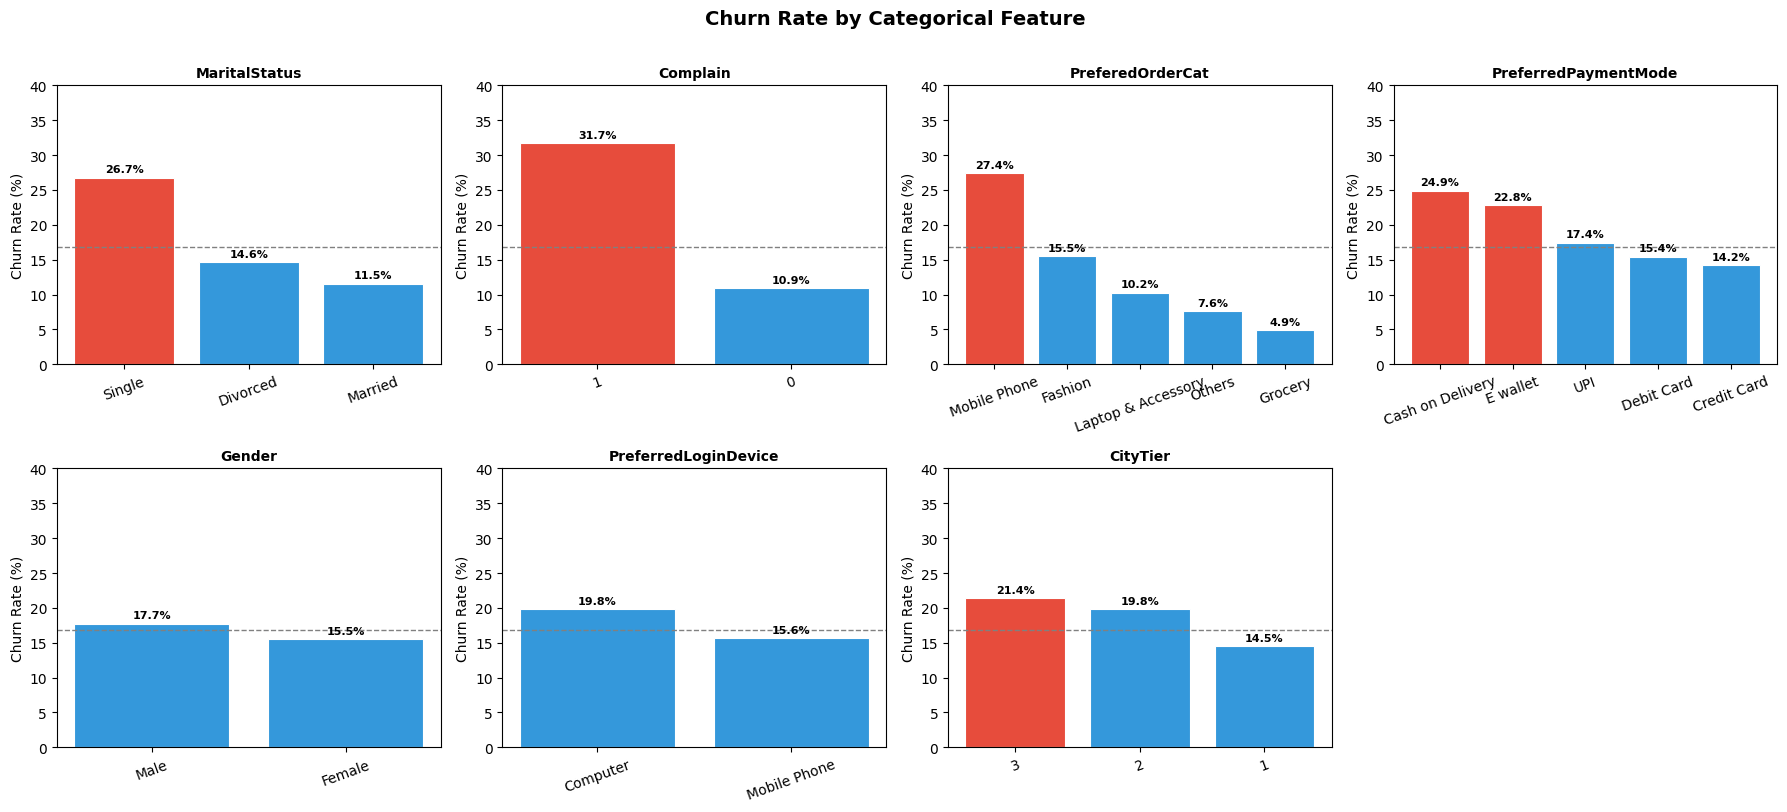

In [61]:
cat_features = [
    "MaritalStatus", "Complain", "PreferedOrderCat",
    "PreferredPaymentMode", "Gender", "PreferredLoginDevice", "CityTier"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df_clean.groupby(col)["Churn"].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=['#e74c3c' if v > 20 else '#3498db' for v in churn_rate.values],
                       edgecolor='white', linewidth=0.8)
    axes[i].axhline(16.8, color='gray', linestyle='--', linewidth=1, label='Overall avg (16.8%)')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_ylim(0, 40)
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[-1].axis('off')
fig.suptitle("Churn Rate by Categorical Feature", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Red bars = notably above the 16.8% overall average

#### Numeric Feature Distributions by Churn

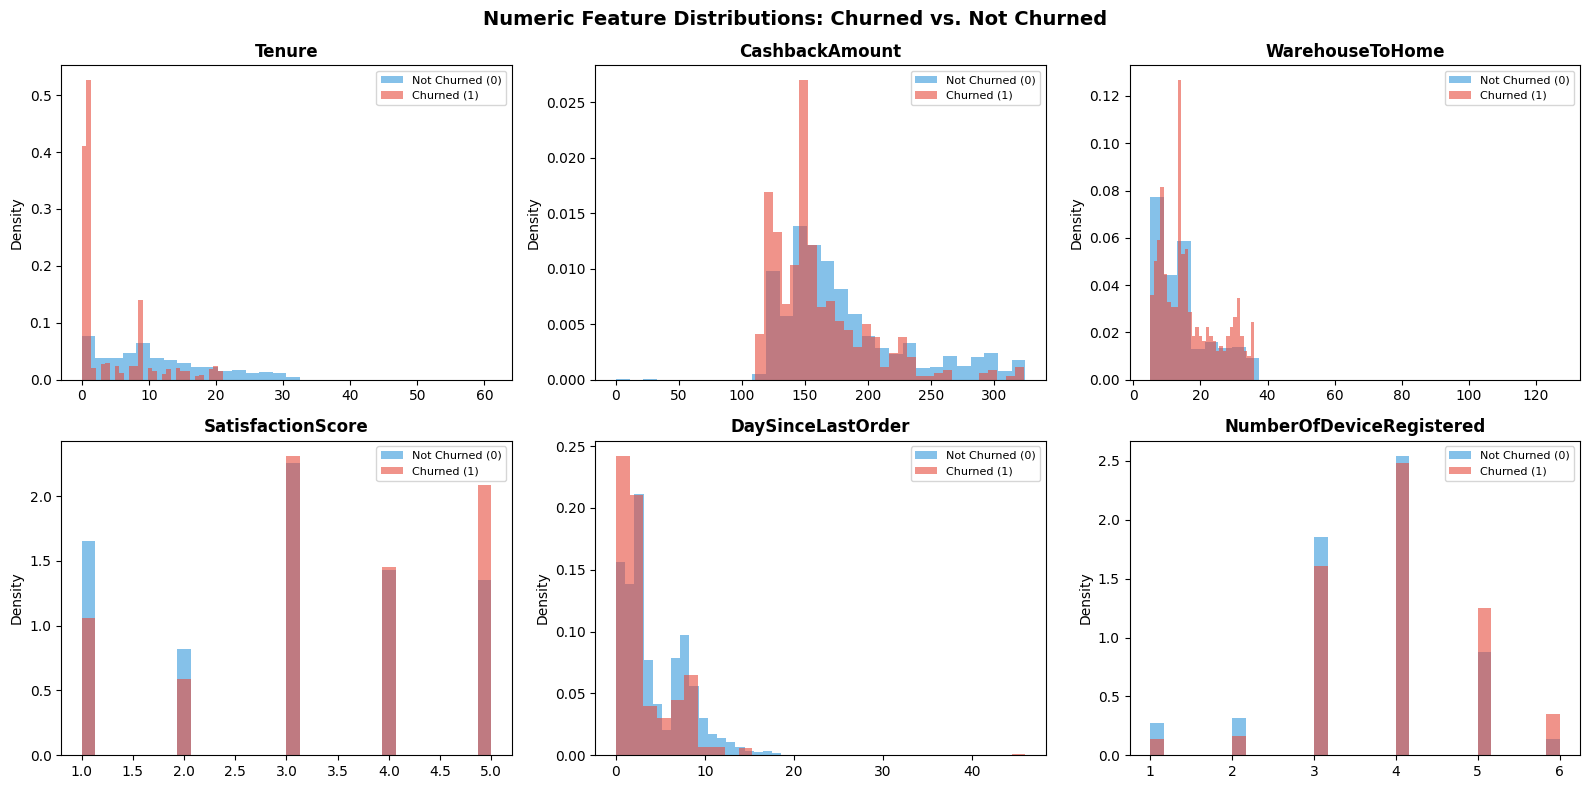

In [ ]:
num_features = ["Tenure", "CashbackAmount", "WarehouseToHome",
                "SatisfactionScore", "DaySinceLastOrder", "NumberOfDeviceRegistered"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = {0: '#3498db', 1: '#e74c3c'}
labels = {0: 'Not Churned (0)', 1: 'Churned (1)'}
# plot histograms for each numeric feature, overlaying churned vs. not churned distributions
for i, col in enumerate(num_features):
    for churn_val in [0, 1]:
        subset = df_clean[df_clean['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=colors[churn_val],
                     label=labels[churn_val], density=True, edgecolor='none')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

fig.suptitle("Numeric Feature Distributions: Churned vs. Not Churned",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Correlation HeatMap

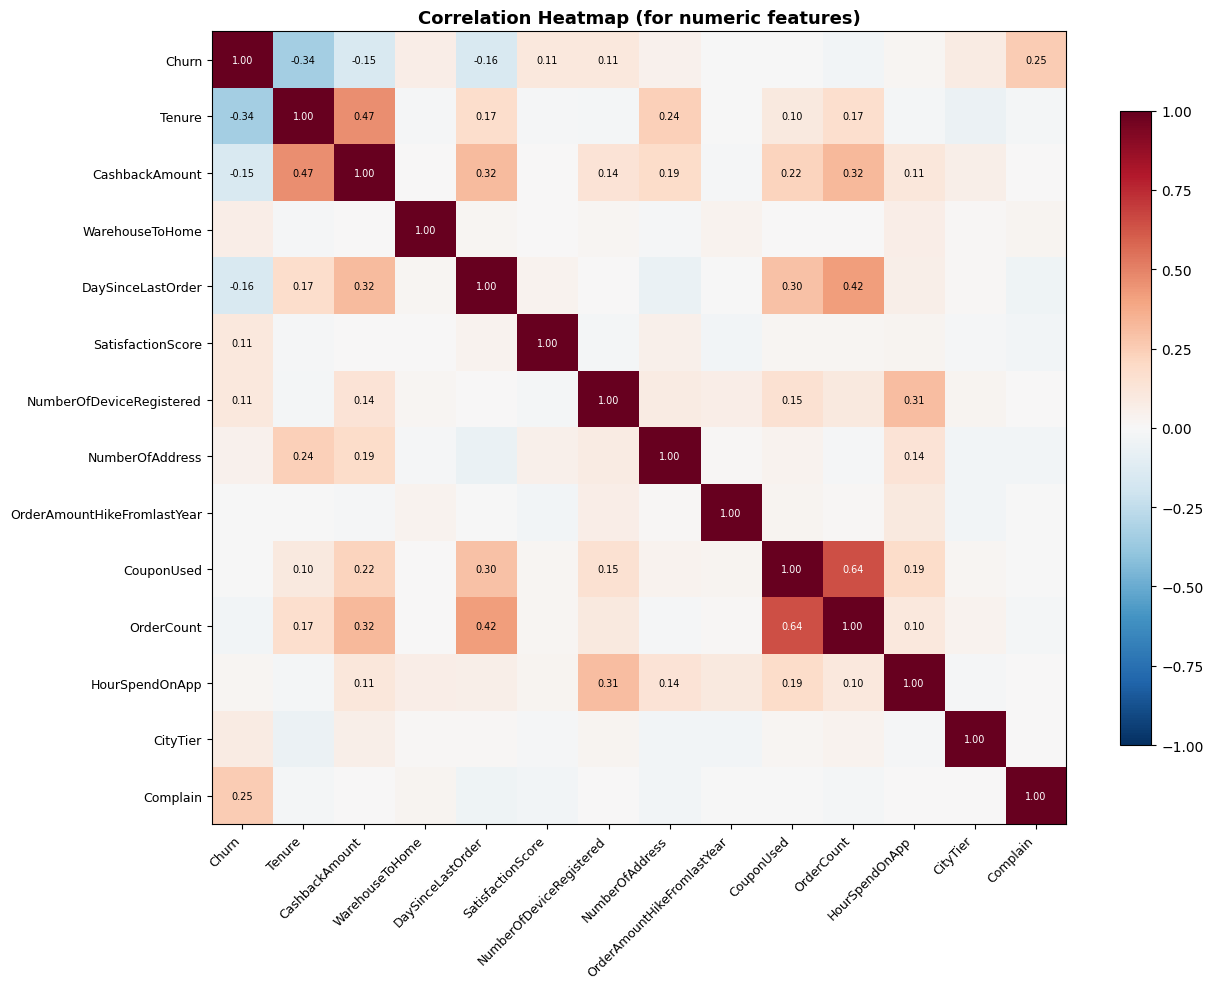


Top correlations with Churn:
Tenure                         0.338
Complain                       0.250
DaySinceLastOrder              0.156
CashbackAmount                 0.154
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
CityTier                       0.085
WarehouseToHome                0.070
NumberOfAddress                0.044
OrderCount                     0.024
HourSpendOnApp                 0.019
OrderAmountHikeFromlastYear    0.007
CouponUsed                     0.001


In [ ]:
num_cols_all = ["Churn", "Tenure", "CashbackAmount", "WarehouseToHome",
                "DaySinceLastOrder", "SatisfactionScore", "NumberOfDeviceRegistered",
                "NumberOfAddress", "OrderAmountHikeFromlastYear", "CouponUsed",
                "OrderCount", "HourSpendOnApp", "CityTier", "Complain"]
# compute correlation matrix for numeric features
corr = df_clean[num_cols_all].corr()

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(num_cols_all)))
ax.set_yticks(range(len(num_cols_all)))
ax.set_xticklabels(num_cols_all, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols_all, fontsize=9)

for i in range(len(num_cols_all)):
    for j in range(len(num_cols_all)):
        val = corr.iloc[i, j]
        if abs(val) > 0.1:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > 0.5 else 'black')

ax.set_title("Correlation Heatmap (for numeric features)", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop correlations with Churn:")
print(corr['Churn'].drop('Churn').abs().sort_values(ascending=False).round(3).to_string())

## Model Preparetion

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# drop CustomerID because it is identifier, not useful feature
df_model = df_clean.drop(columns=["CustomerID"])

# one-hot encode all categorical columns (creates a binary column for each category)
cat_cols = ["PreferredLoginDevice", "PreferredPaymentMode",
            "Gender", "PreferedOrderCat", "MaritalStatus"]
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=False)

# separate features (x) from the target variable (y = Churn)
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# split into test and train sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# scale features to mean=0, std=1 — required for Logistic Regression to work properly
# fit only on train set to avoid leaking test information
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Churn rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
print(f"Total features: {X.shape[1]}")

Train: 4504 rows | Test: 1126 rows
Churn rate — Train: 0.168 | Test: 0.169
Total features: 30


## Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score,
                              precision_score, recall_score, f1_score, roc_curve)

# 1.Logistic Regression 
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)           # hard predictions (0 or 1)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]  # probability of churn (for AUC)

# 2.Decision Tree 
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

# 3.Random Forest 
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# 4. Gradient Boosting 
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]

print("All models trained")

All models trained


## Model Scores

In [66]:
# dict mapping model name to its predictions and  probabilities
models_eval = {
    "Logistic Regression": (lr_pred, lr_prob),
    "Decision Tree":        (dt_pred, dt_prob),
    "Random Forest":        (rf_pred, rf_prob),
    "Gradient Boosting":    (gb_pred, gb_prob),
}

# showing evaluation metrics for each model
for name, (pred, prob) in models_eval.items():
    print(f"\n{'-'*23}")
    print(f"  {name}")
    print(f"{'-'*23}")
  
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Accuracy:  ", round(accuracy_score(y_test, pred), 4))
    print("AUC Score: ", round(roc_auc_score(y_test, prob), 4))
    print("Precision: ", round(precision_score(y_test, pred), 4))
    print("Recall:    ", round(recall_score(y_test, pred), 4))
    print("F1 Score:  ", round(f1_score(y_test, pred), 4))


-----------------------
  Logistic Regression
-----------------------
Confusion Matrix:
[[731 205]
 [ 29 161]]
Accuracy:   0.7922
AUC Score:  0.8856
Precision:  0.4399
Recall:     0.8474
F1 Score:   0.5791

-----------------------
  Decision Tree
-----------------------
Confusion Matrix:
[[726 210]
 [ 31 159]]
Accuracy:   0.786
AUC Score:  0.8769
Precision:  0.4309
Recall:     0.8368
F1 Score:   0.5689

-----------------------
  Random Forest
-----------------------
Confusion Matrix:
[[902  34]
 [ 27 163]]
Accuracy:   0.9458
AUC Score:  0.9851
Precision:  0.8274
Recall:     0.8579
F1 Score:   0.8424

-----------------------
  Gradient Boosting
-----------------------
Confusion Matrix:
[[925  11]
 [ 36 154]]
Accuracy:   0.9583
AUC Score:  0.9877
Precision:  0.9333
Recall:     0.8105
F1 Score:   0.8676


## Model Comparisons

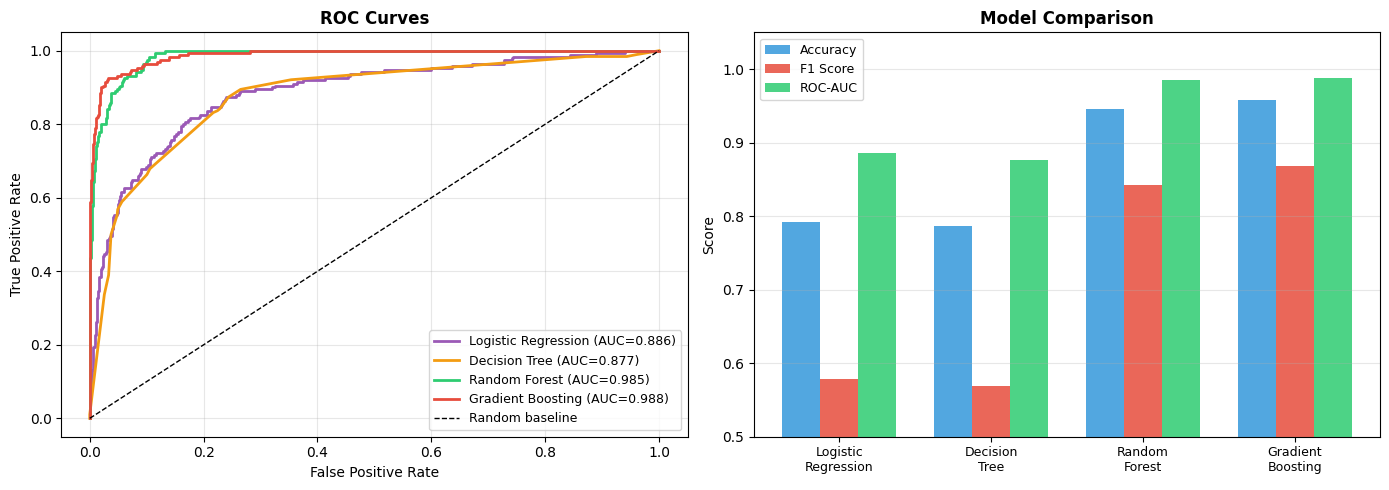

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = ['#9b59b6', '#f39c12', '#2ecc71', '#e74c3c']

# ROC curve plots true positive rate vs false positive rate at every threshold
for (name, (pred, prob)), color in zip(models_eval.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)

# diagonal line represents a random (useless) classifier — all good models should be above it
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bar chart comparing Accuracy, F1, AUC across models 
metrics_data = []
for name, (pred, prob) in models_eval.items():
    metrics_data.append({
        'Model': name.replace(' ', '\n'),  # line break for cleaner x-axis labels
        'Accuracy':   accuracy_score(y_test, pred),
        'F1 Score':   f1_score(y_test, pred),
        'ROC-AUC':    roc_auc_score(y_test, prob),
    })
mdf = pd.DataFrame(metrics_data).set_index('Model')

x = np.arange(len(mdf))
width = 0.25  
for j, (metric, color) in enumerate(zip(['Accuracy', 'F1 Score', 'ROC-AUC'],
                                          ['#3498db', '#e74c3c', '#2ecc71'])):
    axes[1].bar(x + j*width, mdf[metric], width, label=metric, color=color, alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(mdf.index, fontsize=9)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Performance Summary

Below I summarized the evaluation metrics for all four models I tested.
Since the dataset is imbalanced (about 83% not churned and only 17% churned),
I focused on **ROC-AUC and F1 Score** as the main metrics rather than accuracy.
Accuracy is not reliable here because even if a model just predicted "no churn"
for every single customer, it would still get 83% accuracy, which is obviously not useful.

| Model                 | Accuracy | Precision | Recall | F1 Score | ROC-AUC  |
|-----------------------|----------|-----------|--------|----------|----------|
| Logistic Regression   |  79.2%   |   0.4399  | 0.8474 |  0.5791  |  0.8856  |
| Decision Tree         |  78.6%   |   0.4309  | 0.8368 |  0.5689  |  0.8769  |
| Random Forest         |  94.6%   |   0.8274  | 0.8579 |  0.8424  |  0.9851  |
| Gradient Boosting**   |  95.8%   |   0.9333  | 0.8105 |  0.8676  |  0.9877  |

Based on these results, **Gradient Boosting performed the best** with the highest
ROC-AUC (0.9877) and F1 Score (0.8676). Random Forest was very close behind and
also performed really well. Logistic Regression and Decision Tree had similar
accuracy scores to the ensemble models but their F1 Scores were much lower (~0.57),
which again shows that accuracy alone can be deceptive on imbalanced datasets.

#### Confusion Matrices 

Looking at the confusion matrices, I paid most attention to the **False Negatives**
because these are the customers who actually churned but the model predicted they would stay.
These are the most dangerous mistakes because these are the customers the sales team
would never reach out to and lose without knowing it.

| Model               | Correctly Caught Churners (TP)| Missed Churners (FN) | False Alarms (FP) |
|---------------------|-------------------------------|----------------------|-------------------|
| Logistic Regression | 161                           | 29                   | 205               |
| Decision Tree       | 159                           | 31                   | 210               |
| Random Forest       | 163                           | 27                   | 34                |
| Gradient Boosting   | 154                           | 36                   | 11                |

What I found interesting here is the trade-off between Random Forest and Gradient Boosting.
Random Forest actually catches more churners (163 vs 154) but also raises a lot more
false alarms (34 vs 11). Gradient Boosting misses a few more churners but when it does
predict churn, it is almost always right, which makes its alerts much more actionable
for the sales team in practice.

## Feature Importance


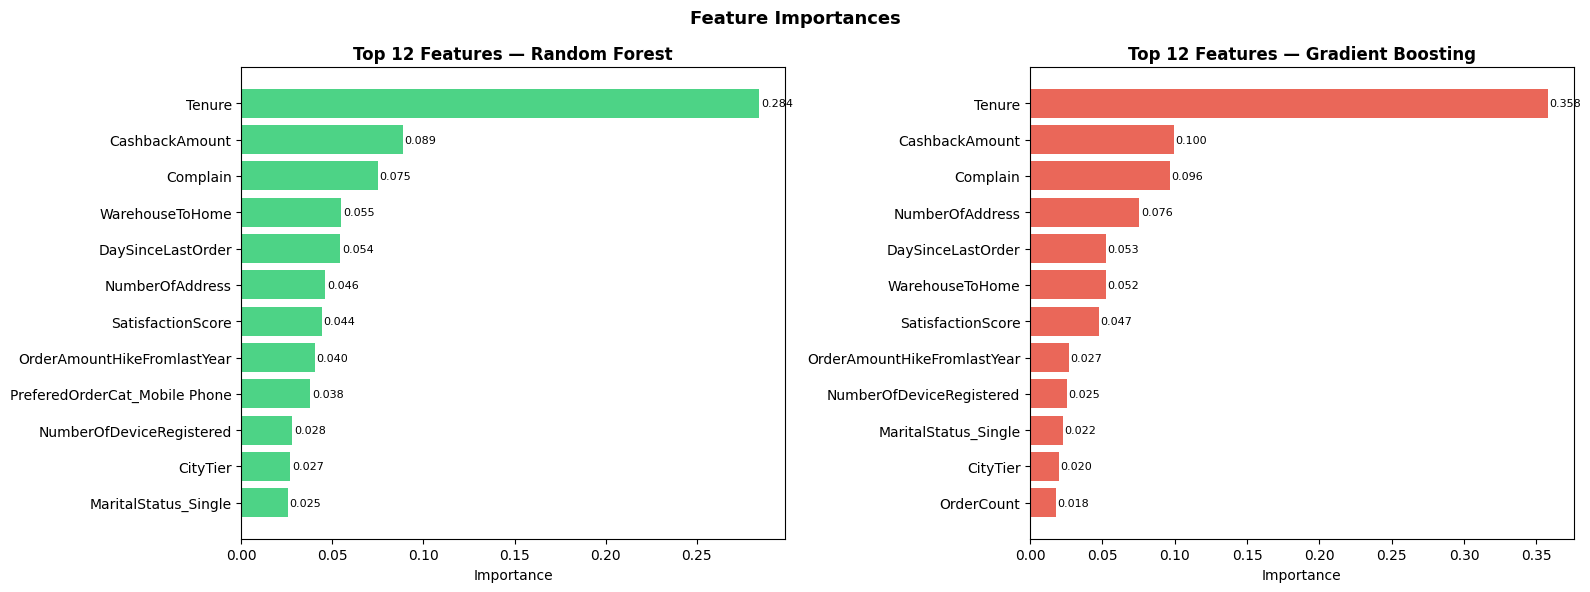

Top 10 Features (Gradient Boosting):
Tenure                         0.3578
CashbackAmount                 0.0997
Complain                       0.0964
NumberOfAddress                0.0756
DaySinceLastOrder              0.0527
WarehouseToHome                0.0521
SatisfactionScore              0.0473
OrderAmountHikeFromlastYear    0.0267
NumberOfDeviceRegistered       0.0252
MaritalStatus_Single           0.0225


In [68]:
# extract feature importances from both tree-based models 
fi_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fi_gb = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 12  # show only top features 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, fi, name, color in zip(axes,
                                [fi_rf.head(top_n), fi_gb.head(top_n)],
                                ['Random Forest', 'Gradient Boosting'],
                                ['#2ecc71', '#e74c3c']):
    # sort ascending so the most important feature appears at the top of the chart
    fi_plot = fi.sort_values(ascending=True)
    bars = ax.barh(fi_plot.index, fi_plot.values, color=color, alpha=0.85)
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Features — {name}', fontweight='bold')
    # add value labels at the end of each bar
    for bar, val in zip(bars, fi_plot.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 Features (Gradient Boosting):")
print(fi_gb.head(10).round(4).to_string())

## Business Insights


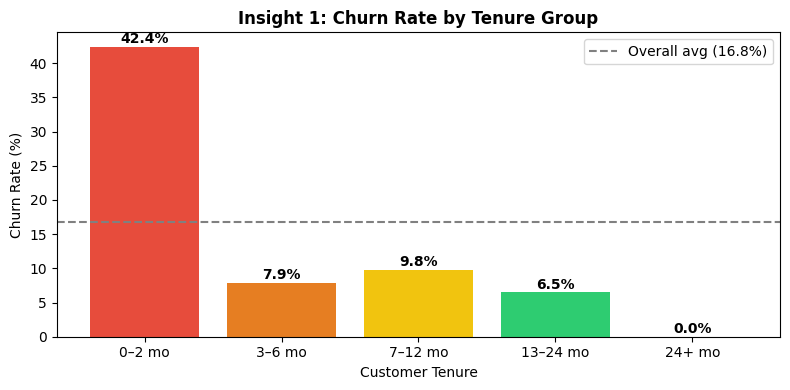

In [69]:
bins   = [0, 2, 6, 12, 24, 62]
labels_tenure = ['0–2 mo', '3–6 mo', '7–12 mo', '13–24 mo', '24+ mo']
df_clean['Tenure_Group'] = pd.cut(df_clean['Tenure'], bins=bins, labels=labels_tenure)

# calculate churn rate and customer count for each tenure group
tenure_churn = df_clean.groupby('Tenure_Group', observed=True)['Churn'].agg(['mean','count'])
tenure_churn['Churn %'] = (tenure_churn['mean'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
# color bars from red (high churn) to blue (low churn) 
bars = ax.bar(tenure_churn.index.astype(str), tenure_churn['Churn %'],
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
# dashed line shows overall average churn rate for reference
ax.axhline(16.8, color='gray', linestyle='--', lw=1.5, label='Overall avg (16.8%)')
# add percentage labels on top of each bar
for bar, val in zip(bars, tenure_churn['Churn %']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val}%', ha='center', fontweight='bold')
ax.set_xlabel('Customer Tenure')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Insight 1: Churn Rate by Tenure Group', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


**Insight**: Customers in their first 0–2 months are the highest churn risk group, so implementing a 90-day onboarding program with check-in touchpoints and first-purchase incentives for new customers can be a soluton

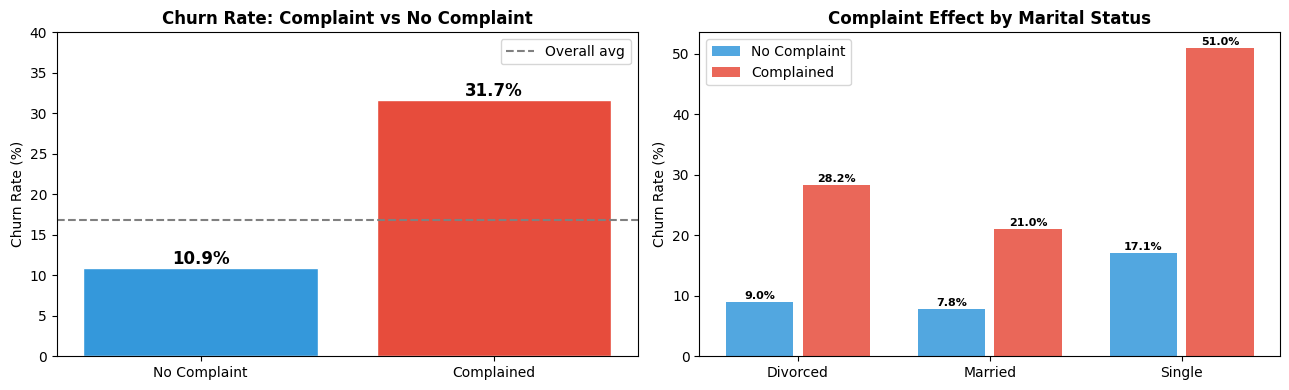

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: overall churn rate for complained vs not complained ---
overall = df_clean.groupby('Complain')['Churn'].mean() * 100
axes[0].bar(['No Complaint', 'Complained'], overall.values,
            color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].axhline(16.8, color='gray', linestyle='--', lw=1.5, label='Overall avg')
for i, v in enumerate(overall.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate: Complaint vs No Complaint', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 40)

# --- Right: complaint effect broken down by marital status ---
# unstack() converts the groupby result into a wide table with one column per Complain value
cross = df_clean.groupby(['MaritalStatus', 'Complain'])['Churn'].mean().unstack() * 100
cross.columns = ['No Complaint', 'Complained']
x = np.arange(len(cross))
# grouped bars — offset by 0.2 so they sit side by side
axes[1].bar(x - 0.2, cross['No Complaint'], 0.35, label='No Complaint', color='#3498db', alpha=0.85)
axes[1].bar(x + 0.2, cross['Complained'],   0.35, label='Complained',   color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cross.index)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Complaint Effect by Marital Status', fontweight='bold')
axes[1].legend()
for i, (nc, c) in enumerate(zip(cross['No Complaint'], cross['Complained'])):
    axes[1].text(i - 0.2, nc + 0.5, f'{nc:.1f}%', ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + 0.2,  c + 0.5, f'{c:.1f}%',  ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


**Insight**: Customers who complained churn at nearly 3× the rate of those who didn't. This effect holds across ALL marital status groups. so action could be: Auto-flag complaints and trigger a retention offer within 24 hours.

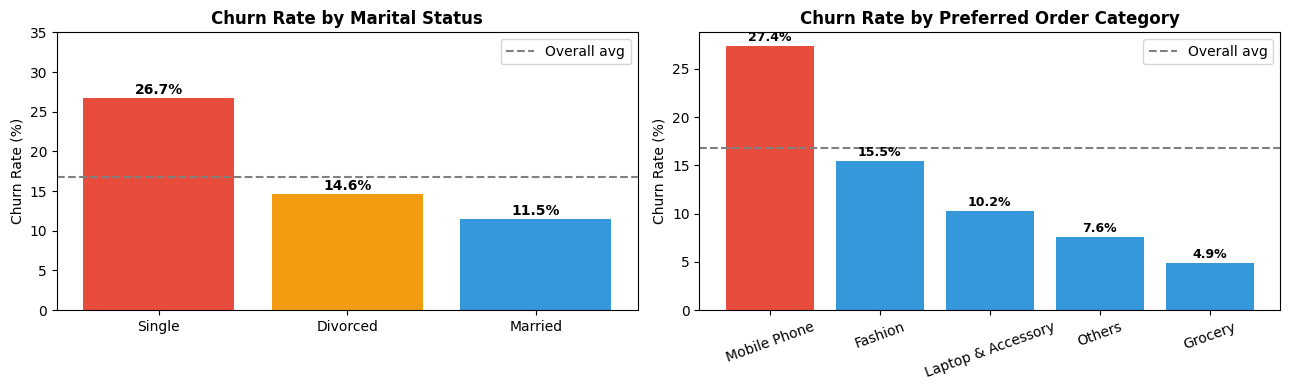

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: churn rate by marital status ---
ms_churn = df_clean.groupby('MaritalStatus')['Churn'].mean() * 100
ms_churn = ms_churn.sort_values(ascending=False)  # highest churn group on the left
bars = axes[0].bar(ms_churn.index, ms_churn.values,
                   color=['#e74c3c','#f39c12','#3498db'])
axes[0].axhline(16.8, color='gray', linestyle='--', lw=1.5, label='Overall avg')
for bar, v in zip(bars, ms_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Marital Status', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 35)

# --- Right: churn rate by preferred order category ---
cat_churn = df_clean.groupby('PreferedOrderCat')['Churn'].mean() * 100
cat_churn = cat_churn.sort_values(ascending=False)
# color bars red if above 20% churn, blue otherwise
colors_cat = ['#e74c3c' if v > 20 else '#3498db' for v in cat_churn.values]
bars2 = axes[1].bar(cat_churn.index, cat_churn.values, color=colors_cat)
axes[1].axhline(16.8, color='gray', linestyle='--', lw=1.5, label='Overall avg')
for bar, v in zip(bars2, cat_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Preferred Order Category', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()


**Insight**: Single customers churn at more than 2× the rate of Married customers. Solution can be: designing loyalty perks targeted at single-user households.

**Insight**: Mobile Phone category buyers have the highest churn of all categories. Offering price-match guarantees or extended warranties for electronics buyers can be solution.

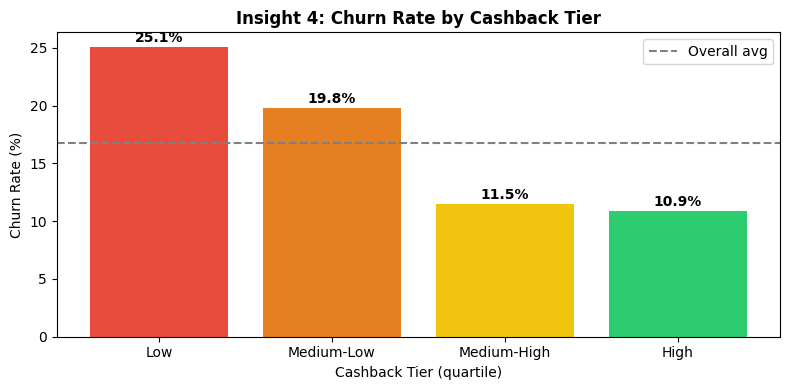

In [72]:
# divide CashbackAmount into 4 equal-sized quartiles (q=4) — Low, Medium-Low, etc.
df_clean['Cashback_Tier'] = pd.qcut(df_clean['CashbackAmount'], q=4,
                                     labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# calculate churn rate and count for each cashback tier
cb_churn = df_clean.groupby('Cashback_Tier', observed=True)['Churn'].agg(['mean','count'])
cb_churn['Churn %'] = (cb_churn['mean'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
# color gradient: red = high churn (low cashback), green = low churn (high cashback)
bars = ax.bar(cb_churn.index.astype(str), cb_churn['Churn %'],
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'])
ax.axhline(16.8, color='gray', linestyle='--', lw=1.5, label='Overall avg')
for bar, v in zip(bars, cb_churn['Churn %']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4,
            f'{v}%', ha='center', fontweight='bold')
ax.set_xlabel('Cashback Tier (quartile)')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Insight 4: Churn Rate by Cashback Tier', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Insight**: Customers receiving the lowest cashback churn significantly more than those receiving the highest cashback rewards. Introducing a tiered cashback rewards program to keep low-cashback customers engaged and reduce their churn risk.

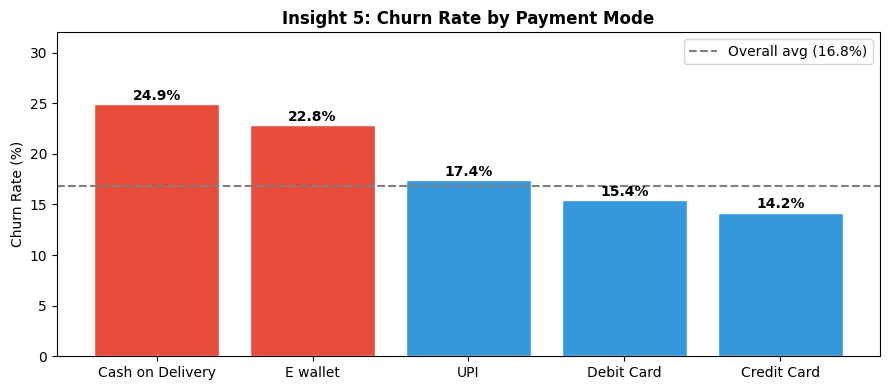

In [73]:
# calculate average churn rate for each payment method
pay_churn = df_clean.groupby('PreferredPaymentMode')['Churn'].mean() * 100
pay_churn = pay_churn.sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
# highlight payment modes with above-20% churn in red
colors_pay = ['#e74c3c' if v > 20 else '#3498db' for v in pay_churn.values]
bars = ax.bar(pay_churn.index, pay_churn.values, color=colors_pay, edgecolor='white')
ax.axhline(16.8, color='gray', linestyle='--', lw=1.5, label='Overall avg (16.8%)')
for bar, v in zip(bars, pay_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4,
            f'{v}%', ha='center', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Insight 5: Churn Rate by Payment Mode', fontweight='bold')
ax.legend()
ax.set_ylim(0, 32)
plt.tight_layout()
plt.show()

**Insight**: Cash on Delivery and E-wallet users churn more than Credit/Debit card users. COD users show low digital platform commitment. Solution can be: Nudge COD users toward digital payment with a one-time cashback incentive on their first card or UPI transaction.

## CONCLUSION of BUSINESS INSIGHTS

1. **Tenure is the most important feature.** Customers in their first 0–2 months
   churn the most. After about 6 months the churn rate drops significantly, so the
   first 90 days are the most critical retention window. A structured onboarding
   program with early incentives would directly address this.

2. **Complaints nearly triple churn probability.** Customers who filed a complaint
   churn at almost 3× the rate of customers who did not, and this pattern holds
   across all marital status groups. Resolving complaints quickly is probably
   the single most impactful action the sales team could take.

3. **Single customers churn more than twice as often as married customers.**
   They likely need different incentives such as referral bonuses or social
   loyalty perks to feel more connected to the platform.

4. **Mobile Phone category buyers have the highest churn rate of all product categories.**
   These customers are probably comparison shopping heavily across platforms.
   Offering price-match guarantees or extended warranties could help retain them.

5. **Cash-on-Delivery users and low-cashback customers are also at higher risk.**
   COD users appear less digitally committed to the platform. A small incentive
   to switch to digital payment, combined with a tiered cashback rewards program,
   would reduce churn risk in both of these segments.
